第三项：项目创新点与项目特色（建议200字左右）
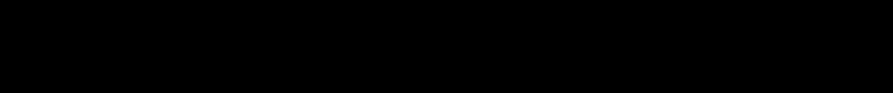
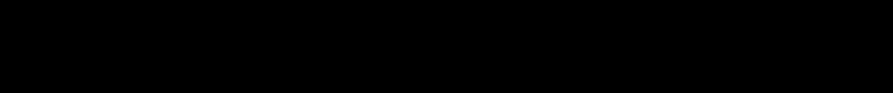

内容：<br>
本项目的核心创新点体现在以下两个方面：<br>

第一项创新在于实现感知评价与客观参数的关联。<br><br>本项目将提出一种融合DSP与深度学习架构的条件单音生成方案，在特征工程阶段依托传统DSP技术提取钢琴单音的物理属性；该方案可将抽象的音色感知评价术语转化为具体的客观量化参数，并将其作为驱动后续深度学习流程的关键依据。<br><br><br>

第二项创新体现在轻量级声纹重建架构的自主设计。<br><br>针对核心的声纹重建环节，本项目摒弃对外部大模型及第三方网络接口的依赖，自主构建并训练轻量级的卷积自编码器（CAE）网络。<br><br>该模型能够深入学习声纹图的潜在分布特征，并将上一步方案提取的客观参数作为条件变量用于调试解码阶段，借此在实现高保真单音生成的同时保障音色控制逻辑的科学性。<br><br>


第四项：系统方案和技术路线（建议1000字左右）<br>
技术关键和设计思路<br>
系统模块图和必要的说明<br>
功能概述（包括子模块的功能）<br>
技术架构图和必要的说明<br>
技术亮点（比如：算法改进、算法创新等）（不需要写）<br>
使用的软件和开发测试环境<br>
开发难度（随便写）

技术关键和设计思路<br>
1. 融合DSP的参数化控制思路<br>
将传统DSP提取的物理特征作为“先验知识”注入神经网络,通过对钢琴单音进行频谱分析，提取出与音色感知相关的关键量化参数，并将其作为条件变量注入。<br>
2. 轻量化CAE架构的技术关键<br>
轻量化CAE架构的技术关键在于编码器与解码器的对称设计：
编码模块：利用卷积层捕获声纹图的空间特征，将高维音频信息压缩至低维潜在空间，提取出单音的本质声纹特征。<br>
注入机制：在隐含层采用特征拼接技术，将DSP参数与声纹特征进行非线性融合，确保生成的音色具备物理真实感。<br>
解码模块：通过转置卷积层将融合特征逐步还原为完整的声纹矩阵，实现高保真的音频重建。<br>
3. 高吞吐量数据管道设计<br>
在实现层面，系统利用TFRecord格式对声纹数据与特征向量进行封装。这种设计显著降低了模型训练时的I/O瓶颈，提高了迭代速度。

系统模块图和必要的说明<br>
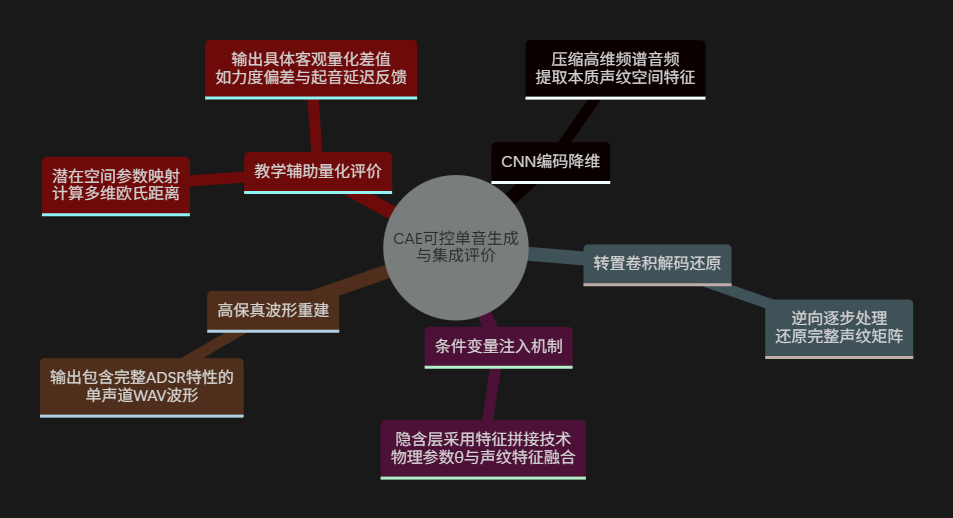

功能概述（包括子模块的功能）<br>
CAE可控单音生成与评价模块功能是整个系统的核心人工智能部分，定位为“条件单音音色生成器”。它摒弃了对外部大模型及第三方网络接口的依赖，通过自主构建并训练轻量级的对称式卷积自编码器网络，学习音频参数到真实波形之间的映射关系。其核心功能是在实现高保真单音生成的同时，保障音色控制逻辑的科学性。<br>

CNN编码降维子模块：利用卷积层捕获高维声纹图的空间特征，将其深度压缩至低维潜在空间中，从而提取出单音本质的声纹特征。<br>

条件变量注入机制子模块：在网络的隐含层中采用特征拼接技术，将客观量化的物理参数 （如音高、力度、明亮度等）作为条件变量，与潜在空间中的声纹特征进行非线性融合。这一机制是实现参数化可控生成的关键，确保了生成的音色具备物理真实感。<br>

转置卷积解码还原子模块：接收隐含层的融合特征，通过转置卷积层进行逆向的逐步处理，将其还原为完整的中间频谱输出。还原的频谱要求为 256×256 分辨率的 2D 浮点数矩阵，且必须能够清晰地呈现出基频（F0）及其对应的各级谐波结构。<br>

高保真波形重建子模块：将频域的声纹矩阵转化为最终的时域音频输出。该子模块生成的音频有着严格的量化标准，时值与输入参数严格对齐，且波形需完整包含起音、衰减、持音与释音（ADSR）四个物理发声阶段。<br>

技术架构图和必要的说明<br>
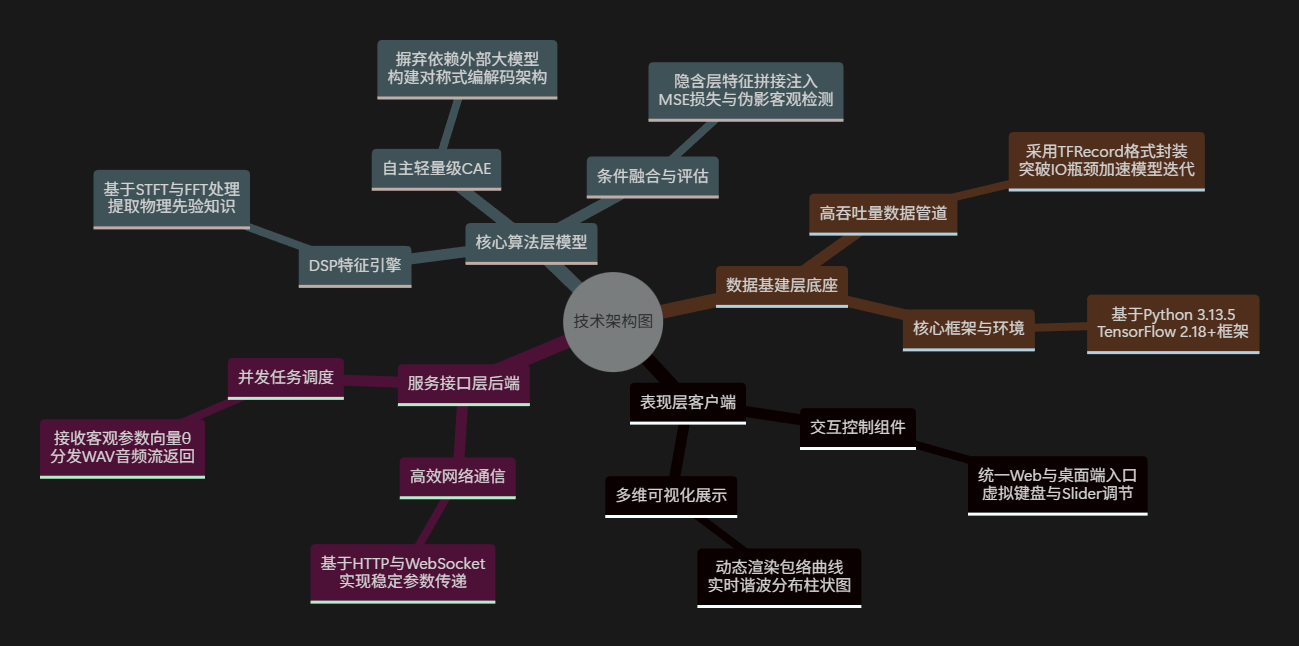

使用的软件和开发测试环境<br>
一、 核心软件环境
集成开发环境 (IDE)：PyCharm 2025.3.2.1 (Professional Edition)，使用Jupyter Notebook。
解释器版本：Python 3.13.5。
深度学习框架：TensorFlow 2.18+。

开发难度<br>
需通过机器学习基础对CNN和CAE进行大量的学习和试错，但市场上同类型的模型有部分可以进行参考，总体而言开发难度适中。<br>

第六项：已有基础

这是神经网络基础课程，通过此视频可以快速上手机器学习的基础概念和CNN的理论。
https://www.bilibili.com/video/BV1EY4y1n7FT/?spm_id_from=333.1387.favlist.content.click&vd_source=58685cfc3cfd593c8c19d0290d8784cf
这是CAE模型的基础介绍，包含了“从无标签数据中自动提取声纹特征”的理论基础。<br>
http://ufldl.stanford.edu/tutorial/unsupervised/Autoencoders/ <br>
这是TensorFlow自带的机器学习教程，对于理论构建和其模型的使用有很详细的讲解。
https://pyimagesearch.com/2020/02/17/autoencoders-with-keras-tensorflow-and-deep-learning/
这篇论文是最接近我们当前内容的，介绍了如何将标签信息作为条件注入 CAE 架构，符合我们监督学习的要求，可以从中找到非常有价值的方法。
C. -H. Hsieh, J. -Y. Chen and B. -H. Nien, "Deep Learning-Based Indoor Localization Using Received Signal Strength and Channel State Information," in IEEE Access, vol. 7, pp. 33256-33267, 2019, doi: 10.1109/ACCESS.2019.2903487.
keywords: {Fingerprint recognition;Receivers;Neural networks;Radio transmitters;Feature extraction;Wireless fidelity;Complexity theory;Indoor localization;deep learning;convolutional neural network (CNN);received signal strength (RSS);channel state information (CSI)},
